# Upload a GIF image and describe it

In [31]:
from IPython.display import display,HTML
from ipywidgets import FileUpload

uploader = FileUpload(accept='.gif', multiple=False)
display(uploader)

FileUpload(value=(), accept='.gif', description='Upload')

In [4]:
print(uploader.value)

({'name': '2e0b84e693f5cd8eba7d17bdf4ff6f9d.gif', 'type': 'image/gif', 'size': 1228606, 'content': <memory at 0x000001F3840FD540>, 'last_modified': datetime.datetime(2025, 11, 8, 9, 40, 5, 916000, tzinfo=datetime.timezone.utc)},)


In [14]:
import base64

# Get the first (and only) uploaded file dict
uploaded_file = uploader.value[0]

# This is a memoryview
content_mv = uploaded_file["content"]

# Convert memoryview -> bytes
img_bytes = bytes(content_mv)  # or content_mv.tobytes()

# Now base64 encode
img_b64 = base64.b64encode(img_bytes).decode("utf-8")
img_data_uri = f"data:image/gif;base64,{img_b64}"



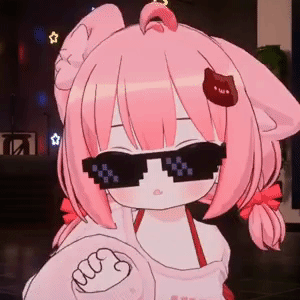

In [15]:
print(img_data_uri)

In [20]:
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage
model = init_chat_model("google_genai:gemini-3.5-flash")

In [21]:
message = HumanMessage([
    {"type": "text", "text": "请描述一下这张gif图片"},
    {"type": "image_url", "image_url": img_data_uri}  # 传入完整的 Data URI
])

response = model.invoke(
    [message]
)

In [29]:
print(response.text)

这张GIF图片展示了一个非常可爱且带有一丝酷感（Cool）的Q版（Chibi）动漫角色在随节奏摇摆。以下是详细描述：

### 1. 角色外貌特征
*   **头发与头部**：角色拥有明亮的**粉红色头发**，额前有齐刘海，两侧扎着可爱的**双马尾**，并用红色蝴蝶结绑住。头顶上有一对毛茸茸的**粉色兽耳**（类似猫耳），右侧刘海处戴着一个深褐色的猫咪/小熊形状的小发卡。
*   **面部配饰**：她戴着一副标志性的**黑色像素风墨镜**（常用于“Thug Life”迷因），遮住了眼睛，嘴角微微露出一个可爱的弧度，形成了一种“又萌又酷”的强烈反差。
*   **服装**：她穿着一件粉色露肩卫衣，内搭一件红色吊带（或泳衣肩带）。
*   **姿势**：她的右手（画面左侧）半握成拳，像小猫爪一样放在胸前。

### 2. 动作与动画效果
*   **摇摆动作**：角色正随着某种隐形的音乐节奏，身体和头部**左右轻轻摇晃**，显得非常惬意和自信，像是在踩点跳舞。
*   **循环效果**：这是一个流畅循环的动图（Looped GIF）。

### 3. 背景
*   背景较暗，看起来像是一个温馨的房间或直播间。
*   背景墙上有几个挂着的**五角星形状的霓虹装饰灯**（有白色、黄色和蓝色），处于微焦虚化状态，营造出一种舒适、梦幻的氛围。

整体给人一种**“虽然外表极度软萌，但戴上墨镜就觉得自己超酷”**的幽默、可爱和治愈感。



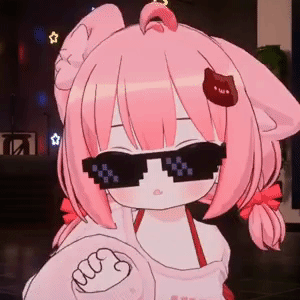

In [32]:
display(HTML(f'<img src="{img_data_uri}" />'))

# Audio input and

In [34]:
# 创建上传组件，接受 .m4a 音频文件
uploader = FileUpload(accept='.m4a', multiple=False)
display(uploader)


FileUpload(value=(), accept='.m4a', description='Upload')

In [35]:
# 等待上传完成后执行以下代码
uploaded_file = uploader.value[0]

In [36]:
# 读取音频文件并编码为 Base64
content_mv = uploaded_file["content"]
audio_bytes = bytes(content_mv)
audio_b64 = base64.b64encode(audio_bytes).decode("utf-8")
audio_data_uri = f"data:audio/mp4;base64,{audio_b64}"

In [42]:
# 构造多模态消息
message = HumanMessage([
    {"type": "text", "text": "请仔细识别这段音频中的歌词，并逐句列出。如果歌词是中文请输出中文，如果是其他语言请保留原文并翻译成中文。"},
    {"type": "audio", "base64": audio_b64, "mime_type": "audio/mp4"}
])

response = model.invoke([message])

In [44]:
print(response.text)

这段音频中的歌词（包含中文及英文歌词与翻译）逐句整理如下：

等你时 太漫长
却不知 只一天 便相聚
那梨花 落落碎
我心碎 是你不可说
我心碎 是你不可说
空留那 昨日世界 已不见

Check it out （瞧一瞧）
What's this? （这是什么？）
Let's go. Let's go. （我们走，我们走）
Hey girl, shake it, shake it （嘿，女孩，尽情摇摆吧）
I want to see you naked （我想看到赤裸的你）
The way you work it, it's making me horny （你舞动身姿的模样，让我兴奋不已）
Hey girl, work it, work it （嘿，女孩，舞动起来吧）
Hey girl, shake it, shake it （嘿，女孩，尽情摇摆吧）
I want to see you naked （我想看到赤裸的你）
The way you work it, it's making me horny （你舞动身姿的模样，让我兴奋不已）
Hey girl, work it, work it （嘿，女孩，舞动起来吧）

那私语 有些小 听不清
月华洒 空寂
梦里 小卒久聚
梦醒 泪已尽
小卒傻 年一过 又一年
晚 更浓夜
平角签 春字常夜
久念 深索躲 红叶
多情 自古凄切
连连落 泪人眼
叙到结 双眼 若如初见

等你时 太漫长
却不知 只一天 便相聚
那梨花 落落碎
我心碎 是你不可说
我心碎 是你不可说
空留那 昨日世界 已不见

（间奏）

等你时 太漫长
却不知 只一天 便相聚
那梨花 落落碎
我心碎 是你不可说
我心碎 是你不可说
空留那 昨日世界 已不见


In [45]:
generate_text = response.text

In [52]:
final_msg = "\n".join(generate_text.split("\n")[2:])
print(final_msg)

等你时 太漫长
却不知 只一天 便相聚
那梨花 落落碎
我心碎 是你不可说
我心碎 是你不可说
空留那 昨日世界 已不见

Check it out （瞧一瞧）
What's this? （这是什么？）
Let's go. Let's go. （我们走，我们走）
Hey girl, shake it, shake it （嘿，女孩，尽情摇摆吧）
I want to see you naked （我想看到赤裸的你）
The way you work it, it's making me horny （你舞动身姿的模样，让我兴奋不已）
Hey girl, work it, work it （嘿，女孩，舞动起来吧）
Hey girl, shake it, shake it （嘿，女孩，尽情摇摆吧）
I want to see you naked （我想看到赤裸的你）
The way you work it, it's making me horny （你舞动身姿的模样，让我兴奋不已）
Hey girl, work it, work it （嘿，女孩，舞动起来吧）

那私语 有些小 听不清
月华洒 空寂
梦里 小卒久聚
梦醒 泪已尽
小卒傻 年一过 又一年
晚 更浓夜
平角签 春字常夜
久念 深索躲 红叶
多情 自古凄切
连连落 泪人眼
叙到结 双眼 若如初见

等你时 太漫长
却不知 只一天 便相聚
那梨花 落落碎
我心碎 是你不可说
我心碎 是你不可说
空留那 昨日世界 已不见

（间奏）

等你时 太漫长
却不知 只一天 便相聚
那梨花 落落碎
我心碎 是你不可说
我心碎 是你不可说
空留那 昨日世界 已不见


In [53]:
model_deepseek = init_chat_model("deepseek-v4-pro")

In [60]:
original_text="""
等什么君演唱的《春庭雪》完整歌词如下：

  庭中梨花谢又一年
  立清宵 月华洒空阶
  梦里笙箫奏旧乐
  梦醒泪染胭脂面
  小重山 念一遍又一遍

  闻 更漏咽 频教前尘辞长夜
  久无眠 深坐对宫檐
  多情最是春庭雪
  年年落满离人苑
  薛涛笺 上言若如初见

  这一世
  太漫长却止步咫尺天涯间
  谁仍记 那梨花若雪时节
  我心匪石不可转
  我心匪席不可卷
  空凝眸 情字深浅无解

  庭中梨花谢又一年
  立清宵 月华洒空阶
  梦里笙箫奏旧乐
  梦醒泪染胭脂面
  小重山 念一遍又一遍

  闻 更漏咽 频教前尘辞长夜
  久无眠 深坐对宫檐
  多情最是春庭雪
  年年落满离人苑
  薛涛笺 上言若如初见

  这一世
  太漫长却止步咫尺天涯间
  谁仍记 那梨花若雪时节
  我心匪石不可转
  我心匪席不可卷
  空凝眸 情字深浅无解

  这一世
  太漫长却止步咫尺天涯间
  谁仍记 那梨花若雪时节
  我心匪石不可转
  我心匪席不可卷
  空凝眸 情字深浅无解

  春欲晚 梨花谢又一年
"""

In [62]:
result = model_deepseek.invoke(f"""
以下是我的AI Agent识别歌曲《春庭雪》的歌词，请你根据这首歌的原来的歌词对我生成的歌词进行客观公正的评分，并说明评分标准评分理由，优点和缺点：
<<<原本的歌词如下>>>
{original_text}

<<<生成的歌词如下>>>
{final_msg}
""")

In [64]:
from IPython.display import display, Markdown

display(Markdown(result.text))

根据你提供的原版歌词作为基准，我对AI生成的歌词进行客观公正的评分如下：

**综合评分：15/100分**
（此分数代表生成歌词在文本质量、主题契合度、艺术性方面的综合表现，满分100分）

### 评分标准及各项得分：

| 评分维度 | 权重 | 得分 | 说明 |
| :--- | :--- | :--- | :--- |
| **内容与主题一致性** | 30% | 0/30 | 与原版歌词凄美、古典、含蓄的中国风主题完全背离，中间插入的英文段落严重违背歌曲基调。 |
| **歌词结构与逻辑** | 25% | 5/25 | 虽有模仿原版“主歌-副歌”的段落感，但内部逻辑断裂，意象堆砌，不知所云。 |
| **语言与意象运用** | 25% | 5/25 | 中文部分有少量古风词汇，但组合混乱、不成意境；英文部分语言粗俗，美感全无。 |
| **韵律与节奏感** | 10% | 5/10 | 中文部分勉强押韵；英文说唱部分有节奏，但与整体割裂。 |
| **独创性与完成度** | 10% | 0/10 | 没有完成一首完整的、可理解的歌词创作，属于失败的作品。 |

---

### 评分理由：

这份生成歌词存在**根本性的、致命的硬伤**，完全不能被视为原歌曲《春庭雪》的有效版本或成功改编。打分主要基于对“生成内容是否完成基础任务”的最低限度要求，分数极低的原因是它在核心任务上已失败。

---

### 优缺点分析：

#### 致命缺点（失败的根本原因）：

1.  **主题与风格的彻底撕裂（最致命问题）**：
    -   **原版**：一以贯之的凄婉、典雅、深情，充满古典诗词的意境和含蓄的离愁。
    -   **生成版**：整体是试图模仿古风的破碎中文，但中间突兀地插入一段 **“Check it out... I want to see you naked... making me horny”** 的英文性暗示说唱。这是对原词情境毁灭性的破坏，将一首深情哀婉的中国风歌曲瞬间变成了低俗的夜店舞曲，完全不可接受。

2.  **中文词句逻辑混乱、意象堆砌**：
    -   **不通顺的句子**：如“小卒傻 年一过 又一年”、“平角签 春字常夜”、“久念 深索躲 红叶”、“叙到结 双眼”等，基本属于无意义的汉字拼凑，读者无法理解其想表达的内容。
    -   **意象错用**：原词中的“薛涛笺”（唐代才女薛涛所制的精美诗笺，情书象征）被生硬地写成“叙到结 双眼”，美感与典故尽失。原词“我心匪石不可转”（出自《诗经》，比喻爱情坚贞）这一核心深情告白，被替换为“我心碎 是你不可说”，其文化底蕴和情感力度一落千丈。

3.  **结构上的失败模仿**：
    -   生成词试图模仿“梨花谢又一年”、“梦里/梦醒”、“小重山”等原词结构和元素，但变成了“那梨花 落落碎”、“梦里 小卒久聚”、“小卒傻”，画虎不成反类犬，将原词优雅的时光流逝感变成了滑稽的呓语。

#### 微乎其微的“优点”（在整体失败的前提下）：

1.  **局部用词有古风倾向**：如“月华洒”、“梦醒 泪已尽”等少数几个短句，如果脱离上下文，单独看还保留了一丝古风歌词的特征。这说明模型可能“知道”这个任务需要“古风词汇”，但完全不具备组合它们的能力。
2.  **英文段落的节奏**：那段格格不入的英文，作为一段完全独立的、低俗的夜店说唱，其节奏和韵脚是存在的。但这一点在此任务中不能视为优点，恰恰是它最大的败笔。

### 总结：
这份AI生成的歌词是**一次灾难性的失败尝试**。它没有理解原歌词的深刻意境和文化内核，其输出结果是支离破碎的中文和低俗英文的强行拼接，完全不具备作为歌曲《春庭雪》歌词的任何价值。